# An Introduction to SageMaker ObjectToVec model for sequence-sequence embedding


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

---


## Table of contents

1. [Background](#Background)
1. [Download datasets](#Download-datasets)
1. [Preprocessing](#Preprocessing)
1. [Model training and inference](#Model-training-and-inference)
1. [Transfer learning with object2vec](#Transfer-learning)
1. [How to enable the optimal training result](#How-to-enable-the-optimal-training-result)
1. [Hyperparameter Tuning (Advanced)](#Hyperparameter-Tuning-(Advanced))

## Background

*Object2Vec* is a highly customizable multi-purpose algorithm that can learn embeddings of pairs of objects. The embeddings are learned in a way that it preserves their pairwise **similarities**
- **Similarity** is user-defined: users need to provide the algorithm with pairs of objects that they define as similar (1) or dissimilar (0); alternatively, the users can define similarity in a continuous sense (provide a real-valued similarity score for reach object pair)
- The learned embeddings can be used to compute nearest neighbors of objects, as well as to visualize natural clusters of related objects in the embedding space. In addition, the embeddings can also be used as features of the corresponding objects in downstream supervised tasks such as classification or regression

### Using Object2Vec to Encode Sentences into Fixed Length Embeddings 

In this notebook, we will demonstrate how to train *Object2Vec* to encode sequences of varying length into fixed length embeddings. 

As a specific example, we will represent each sentence as a sequence of integers, and we will show how to learn an encoder to embed these sentences into fixed-length vectors. To this end, we need pairs of sentences with labels that indicate their similarity. The Stanford Natural Language Inference data set (https://nlp.stanford.edu/projects/snli/), which consists
of pairs of sentences labeled as "entailment", "neutral" or "contradiction", comes close to our requirements; we will pick this data set as our training dataset in this notebook example. 

Once the model is trained on this data,
the trained encoders can be used to convert any new English sentences into fixed length embeddings. We will measure the quality of learned sentence embeddings on new sentences, by computing similarity of sentence pairs in the embedding space from the STS'16 dataset (http://alt.qcri.org/semeval2016/task1/), and evaluating against human-labeled ground-truth ratings.

<img style="float:middle" src="image_snli.png" width="480">

### Before running the notebook
- Please use a Python 3 kernel for the notebook
- Please make sure you have `jsonlines` and `nltk` packages installed

##### (If you haven't done it) install jsonlines and nltk

In [1]:
# [exec-copy] pip installs disabled; deps preinstalled in venv
pass

## Download datasets

Please be aware of the following requirements about acknowledgment, copyright and availability, cited from the [dataset description page](https://nlp.stanford.edu/projects/snli/).
> The Stanford Natural Language Inference Corpus by The Stanford NLP Group is licensed under a Creative Commons Attribution-ShareAlike 4.0 International License.
Based on a work at http://shannon.cs.illinois.edu/DenotationGraph

In [2]:
import os
import requests
import io
import numpy as np
from zipfile import ZipFile
from datetime import datetime

In [3]:
SNLI_PATH = "snli_1.0"
STS_PATH = "sts2016-english-with-gs-v1.0"

if not os.path.exists(SNLI_PATH):
    url_address = "https://nlp.stanford.edu/projects/snli/snli_1.0.zip"
    request = requests.get(url_address)
    zfile = ZipFile(io.BytesIO(request.content))
    zfile.extractall()
    zfile.close()

if not os.path.exists(STS_PATH):
    url_address = (
        "http://alt.qcri.org/semeval2016/task1/data/uploads/sts2016-english-with-gs-v1.0.zip"
    )
    request = requests.get(url_address)
    zfile = ZipFile(io.BytesIO(request.content))
    zfile.extractall()

## Preprocessing

In [4]:
import boto3
import sys, os
import jsonlines
import json
from collections import Counter
from itertools import chain, islice
from nltk.tokenize import TreebankWordTokenizer

In [5]:
# constants

BOS_SYMBOL = "<s>"
EOS_SYMBOL = "</s>"
UNK_SYMBOL = "<unk>"
PAD_SYMBOL = "<pad>"
PAD_ID = 0
TOKEN_SEPARATOR = " "
VOCAB_SYMBOLS = [PAD_SYMBOL, UNK_SYMBOL, BOS_SYMBOL, EOS_SYMBOL]


LABEL_DICT = {"entailment": 0, "neutral": 1, "contradiction": 2}

In [6]:
#### Utility functions


def read_jsonline(fname):
    """
    Reads jsonline files and returns iterator
    """
    with jsonlines.open(fname) as reader:
        for line in reader:
            yield line


def sentence_to_integers(sentence, tokenizer, word_dict):
    """
    Converts a string of tokens to a list of integers
    TODO: Better handling of the case
          where token is not in word_dict
    """
    return [word_dict[token] for token in get_tokens(sentence, tokenizer) if token in word_dict]


def get_tokens(line, tokenizer):
    """
    Yields tokens from input string.

    :param line: Input string.
    :return: Iterator over tokens.
    """
    for token in tokenizer.tokenize(line):
        if len(token) > 0:
            yield token


def get_tokens_from_snli(input_dict, tokenizer):
    iter_list = list()
    for sentence_key in ["sentence1", "sentence2"]:
        sentence = input_dict[sentence_key]
        iter_list.append(get_tokens(sentence, tokenizer))
    return chain(iter_list[0], iter_list[1])


def get_tokens_from_sts(input_sentence_pair, tokenizer):
    iter_list = list()
    for s in input_sentence_pair:
        iter_list.append(get_tokens(s, tokenizer))
    return chain(iter_list[0], iter_list[1])


def resolve_snli_label(raw_label):
    """
    Converts raw label to integer
    """
    return LABEL_DICT[raw_label]

#### Functions to build vocabulary from SNLI corpus

In [7]:
def build_vocab(
    data_iter, dataname="snli", num_words=50000, min_count=1, use_reserved_symbols=True, sort=True
):
    """
    Creates a vocabulary mapping from words to ids. Increasing integer ids are assigned by word frequency,
    using lexical sorting as a tie breaker. The only exception to this are special symbols such as the padding symbol
    (PAD).

    :param data_iter: Sequence of sentences containing whitespace delimited tokens.
    :param num_words: Maximum number of words in the vocabulary.
    :param min_count: Minimum occurrences of words to be included in the vocabulary.
    :return: word-to-id mapping.
    """
    vocab_symbols_set = set(VOCAB_SYMBOLS)
    tokenizer = TreebankWordTokenizer()
    if dataname == "snli":
        raw_vocab = Counter(
            token
            for line in data_iter
            for token in get_tokens_from_snli(line, tokenizer)
            if token not in vocab_symbols_set
        )
    elif dataname == "sts":
        raw_vocab = Counter(
            token
            for line in data_iter
            for token in get_tokens_from_sts(line, tokenizer)
            if token not in vocab_symbols_set
        )
    else:
        raise NameError(f"Data name {dataname} is not recognized!")

    print("Initial vocabulary: {} types".format(len(raw_vocab)))

    # For words with the same count, they will be ordered reverse alphabetically.
    # Not an issue since we only care for consistency
    pruned_vocab = sorted(((c, w) for w, c in raw_vocab.items() if c >= min_count), reverse=True)
    print("Pruned vocabulary: {} types (min frequency {})".format(len(pruned_vocab), min_count))

    # truncate the vocabulary to fit size num_words (only includes the most frequent ones)
    vocab = islice((w for c, w in pruned_vocab), num_words)

    if sort:
        # sort the vocabulary alphabetically
        vocab = sorted(vocab)
    if use_reserved_symbols:
        vocab = chain(VOCAB_SYMBOLS, vocab)

    word_to_id = {word: idx for idx, word in enumerate(vocab)}

    print("Final vocabulary: {} types".format(len(word_to_id)))

    if use_reserved_symbols:
        # Important: pad symbol becomes index 0
        assert word_to_id[PAD_SYMBOL] == PAD_ID
    return word_to_id

#### Functions to convert SNLI data to pairs of sequences of integers

In [8]:
def convert_snli_to_integers(data_iter, word_to_id, dirname=SNLI_PATH, fname_suffix=""):
    """
    Go through snli jsonline file line by line and convert sentences to list of integers
    - convert entailments to labels
    """
    fname = "snli-integer-" + fname_suffix + ".jsonl"
    path = os.path.join(dirname, fname)
    tokenizer = TreebankWordTokenizer()
    count = 0
    max_seq_length = 0
    with jsonlines.open(path, mode="w") as writer:
        for in_dict in data_iter:
            # in_dict = json.loads(line)
            out_dict = dict()
            rlabel = in_dict["gold_label"]
            if rlabel in LABEL_DICT:
                rsentence1 = in_dict["sentence1"]
                rsentence2 = in_dict["sentence2"]
                for idx, sentence in enumerate([rsentence1, rsentence2]):
                    # print(count, sentence)
                    s = sentence_to_integers(sentence, tokenizer, word_to_id)
                    out_dict[f"in{idx}"] = s
                    count += 1
                    max_seq_length = max(len(s), max_seq_length)
                out_dict["label"] = resolve_snli_label(rlabel)
                writer.write(out_dict)
            else:
                count += 1
    print(f"There are in total {count} invalid labels")
    print(f"The max length of converted sequence is {max_seq_length}")

### Generate vocabulary from SNLI data

In [9]:
def make_snli_full_vocab(dirname=SNLI_PATH, force=True):
    vocab_path = os.path.join(dirname, "snli-vocab.json")
    if not os.path.exists(vocab_path) or force:
        data_iter_list = list()
        for fname_suffix in ["train", "test", "dev"]:
            fname = "snli_1.0_" + fname_suffix + ".jsonl"
            data_iter_list.append(read_jsonline(os.path.join(dirname, fname)))
        data_iter = chain(data_iter_list[0], data_iter_list[1], data_iter_list[2])
        with open(vocab_path, "w") as write_file:
            word_to_id = build_vocab(
                data_iter, num_words=50000, min_count=1, use_reserved_symbols=False, sort=True
            )
            json.dump(word_to_id, write_file)


make_snli_full_vocab(force=False)

### Generate tokenized SNLI data as sequences of integers
- We use the SNLI vocabulary as a lookup dictionary to convert SNLI sentence pairs into sequences of integers

In [10]:
def make_snli_data(dirname=SNLI_PATH, vocab_file="snli-vocab.json", outfile_suffix="", force=True):
    for fname_suffix in ["train", "test", "validation"]:
        outpath = os.path.join(dirname, f"snli-integer-{fname_suffix}-{outfile_suffix}.jsonl")
        if not os.path.exists(outpath) or force:
            if fname_suffix == "validation":
                inpath = os.path.join(dirname, f"snli_1.0_dev.jsonl")
            else:
                inpath = os.path.join(dirname, f"snli_1.0_{fname_suffix}.jsonl")
            data_iter = read_jsonline(inpath)
            vocab_path = os.path.join(dirname, vocab_file)
            with open(vocab_path, "r") as f:
                word_to_id = json.load(f)
            convert_snli_to_integers(
                data_iter,
                word_to_id,
                dirname=dirname,
                fname_suffix=f"{fname_suffix}-{outfile_suffix}",
            )


make_snli_data(force=False)

## Model training and inference

### Training

In [11]:
def get_vocab_size(vocab_path):
    with open(vocab_path) as f:
        word_to_id = json.load(f)
        return len(word_to_id.keys())


vocab_path = os.path.join(SNLI_PATH, "snli-vocab.json")
vocab_size = get_vocab_size(vocab_path)
print("There are {} words in vocabulary {}".format(vocab_size, vocab_path))

There are 43540 words in vocabulary snli_1.0/snli-vocab.json


For the runs in this notebook, we will use the Hierarchical CNN architecture to encode each of the sentences into fixed length embeddings. Some of the other hyperparameters are shown below.

In [12]:
## Define hyperparameters and define S3 input path
DEFAULT_HP = {
    "enc_dim": 4096,
    "mlp_dim": 512,
    "mlp_activation": "linear",
    "mlp_layers": 2,
    "output_layer": "softmax",
    "optimizer": "adam",
    "learning_rate": 0.0004,
    "mini_batch_size": 32,
    "epochs": 20,
    "bucket_width": 0,
    "early_stopping_tolerance": 0.01,
    "early_stopping_patience": 3,
    "dropout": 0,
    "weight_decay": 0,
    "enc0_max_seq_len": 82,
    "enc1_max_seq_len": 82,
    "enc0_network": "hcnn",
    "enc1_network": "enc0",
    "enc0_token_embedding_dim": 300,
    "enc0_layers": "auto",
    "enc0_cnn_filter_width": 3,
    "enc1_token_embedding_dim": 300,
    "enc1_layers": "auto",
    "enc1_cnn_filter_width": 3,
    "enc0_vocab_file": "",
    "enc1_vocab_file": "",
    "enc0_vocab_size": vocab_size,
    "enc1_vocab_size": vocab_size,
    "num_classes": 3,
    "_num_gpus": "auto",
    "_num_kv_servers": "auto",
    "_kvstore": "device",
}

### Define input data channel and output path in S3

In [13]:
import boto3
from sagemaker.core.helper.session_helper import Session

boto_sess = boto3.Session(region_name="us-west-1")
sess = Session(boto_session=boto_sess)
bucket = sess.default_bucket()
default_bucket_prefix = sess.default_bucket_prefix

[07/13/26 12:54:06] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12625319;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12625320;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


In [14]:
## Input data bucket and prefix
prefix = "object2vec/input/"

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    prefix = f"{default_bucket_prefix}/{prefix}"

input_path = os.path.join("s3://", bucket, prefix)
print(f"Data path for training is {input_path}")
## Output path
output_prefix = "object2vec/output/"
output_bucket = bucket
output_path = os.path.join("s3://", output_bucket, output_prefix)
print(f"Trained model will be saved at {output_path}")

Data path for training is s3://sagemaker-us-west-1-729646638167/object2vec/input/
Trained model will be saved at s3://sagemaker-us-west-1-729646638167/object2vec/output/


### Initialize SageMaker training job configuration
- Get IAM role and the ObjectToVec algorithm container image

In [15]:
import boto3
from sagemaker.core import image_uris

region = "us-west-1"
role = "arn:aws:iam::729646638167:role/SageMakerRole"
print(role)

container = image_uris.retrieve("object2vec", region)
print(f"Using SageMaker Object2Vec container: {container} ({region})")

[07/13/26 12:54:07] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12625325;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12625326;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

arn:aws:iam::729646638167:role/SageMakerRole


                    INFO     Same images used for training and inference. Defaulting to image     ]8;id=12625333;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=12625334;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#398\398]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=12625340;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=12625341;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#535\535]8;;\

Using SageMaker Object2Vec container: 632365934929.dkr.ecr.us-west-1.amazonaws.com/object2vec:1 (us-west-1)


In [16]:
from sagemaker.core.shapes import Channel, DataSource, S3DataSource


def set_training_environment(
    bucket,
    prefix,
    base_hyperparameters=DEFAULT_HP,
    is_quick_run=True,
    is_pretrain=False,
    use_all_vocab={},
):
    """Upload data to S3 and build V3 sagemaker-core input Channels.

    Returns (hyperparameters, input_channels) where input_channels is a list
    of sagemaker.core.shapes.Channel objects consumed by TrainingJob.create.
    """
    input_channels = []
    s3_client = boto3.client("s3")
    for split in ["train", "validation"]:
        if is_pretrain:
            fname_in = f"all_vocab_datasets/snli-integer-{split}-pretrain.jsonl"
            fname_out = f"{split}/snli-integer-{split}-pretrain.jsonl"
        else:
            fname_in = os.path.join(SNLI_PATH, f"snli-integer-{split}-.jsonl")
            fname_out = f"{split}/snli-integer-{split}.jsonl"

        s3_client.upload_file(fname_in, bucket, os.path.join(prefix, fname_out))
        input_channels.append(
            Channel(
                channel_name=split,
                data_source=DataSource(
                    s3_data_source=S3DataSource(
                        s3_data_type="S3Prefix",
                        s3_uri=input_path + fname_out,
                        s3_data_distribution_type="ShardedByS3Key",
                    )
                ),
                content_type="application/jsonlines",
            )
        )

        print("Uploaded {} data to {}".format(split, input_path + fname_out))

    hyperparameters = base_hyperparameters.copy()

    if use_all_vocab:
        hyperparameters["enc0_vocab_file"] = "all_vocab.json"
        hyperparameters["enc1_vocab_file"] = "all_vocab.json"
        hyperparameters["enc0_vocab_size"] = use_all_vocab["vocab_size"]
        hyperparameters["enc1_vocab_size"] = use_all_vocab["vocab_size"]

    if is_pretrain:
        ## set up auxliary channel
        aux_path = os.path.join(prefix, "auxiliary")
        # upload auxiliary files
        assert os.path.exists("GloVe/glove.840B-trim.txt"), "Pretrained embedding does not exist!"
        s3_client.upload_file(
            "GloVe/glove.840B-trim.txt", bucket, os.path.join(aux_path, "glove.840B-trim.txt")
        )
        if use_all_vocab:
            s3_client.upload_file(
                "all_vocab_datasets/all_vocab.json",
                bucket,
                os.path.join(aux_path, "all_vocab.json"),
            )
        else:
            s3_client.upload_file(
                "snli_1.0/snli-vocab.json", bucket, os.path.join(aux_path, "snli-vocab.json")
            )

        input_channels.append(
            Channel(
                channel_name="auxiliary",
                data_source=DataSource(
                    s3_data_source=S3DataSource(
                        s3_data_type="S3Prefix",
                        s3_uri="s3://" + bucket + "/" + aux_path,
                        s3_data_distribution_type="FullyReplicated",
                    )
                ),
                content_type="application/json",
            )
        )

        print(
            "Uploaded auxiliary data for initializing with pretrain-embedding to {}".format(
                aux_path
            )
        )

        # add pretrained_embedding_file name to hyperparameters
        for idx in [0, 1]:
            hyperparameters[f"enc{idx}_pretrained_embedding_file"] = "glove.840B-trim.txt"

    if is_quick_run:
        hyperparameters["mini_batch_size"] = 8192
        hyperparameters["enc_dim"] = 16
        hyperparameters["epochs"] = 2
    else:
        hyperparameters["mini_batch_size"] = 256
        hyperparameters["enc_dim"] = 8192
        hyperparameters["epochs"] = 20

    # sagemaker-core requires hyperparameter values to be strings
    hyperparameters = {k: str(v) for k, v in hyperparameters.items()}
    return hyperparameters, input_channels

### Train without using pretrained embedding

In [17]:
from time import gmtime, strftime
from sagemaker.core.resources import TrainingJob
from sagemaker.core.shapes import (
    AlgorithmSpecification,
    ResourceConfig,
    StoppingCondition,
    OutputDataConfig,
)

## set up training environment
"""
- To get good training result, set is_quick_run to False
- To test-run the algorithm quickly, set is_quick_run to True
"""
hyperparameters, input_channels = set_training_environment(
    bucket, prefix, is_quick_run=True, is_pretrain=False, use_all_vocab={}
)
hyperparameters

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12625346;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12625347;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Uploaded train data to s3://sagemaker-us-west-1-729646638167/object2vec/input/train/snli-integer-train.jsonl
Uploaded validation data to s3://sagemaker-us-west-1-729646638167/object2vec/input/validation/snli-integer-validation.jsonl


{'enc_dim': '16',
 'mlp_dim': '512',
 'mlp_activation': 'linear',
 'mlp_layers': '2',
 'output_layer': 'softmax',
 'optimizer': 'adam',
 'learning_rate': '0.0004',
 'mini_batch_size': '8192',
 'epochs': '2',
 'bucket_width': '0',
 'early_stopping_tolerance': '0.01',
 'early_stopping_patience': '3',
 'dropout': '0',
 'weight_decay': '0',
 'enc0_max_seq_len': '82',
 'enc1_max_seq_len': '82',
 'enc0_network': 'hcnn',
 'enc1_network': 'enc0',
 'enc0_token_embedding_dim': '300',
 'enc0_layers': 'auto',
 'enc0_cnn_filter_width': '3',
 'enc1_token_embedding_dim': '300',
 'enc1_layers': 'auto',
 'enc1_cnn_filter_width': '3',
 'enc0_vocab_file': '',
 'enc1_vocab_file': '',
 'enc0_vocab_size': '43540',
 'enc1_vocab_size': '43540',
 'num_classes': '3',
 '_num_gpus': 'auto',
 '_num_kv_servers': 'auto',
 '_kvstore': 'device'}

In [18]:
%%time
training_job_name = f"object2vec-snli-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"

training_job = TrainingJob.create(
    training_job_name=training_job_name,
    hyper_parameters=hyperparameters,
    algorithm_specification=AlgorithmSpecification(
        training_image=container,
        training_input_mode="File",
    ),
    role_arn=role,
    input_data_config=input_channels,
    output_data_config=OutputDataConfig(s3_output_path=output_path),
    resource_config=ResourceConfig(
        instance_type="ml.g4dn.xlarge",
        instance_count=1,
        volume_size_in_gb=30,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=360000),
)

training_job.wait(logs=True)
print(training_job.training_job_status)

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


[07/13/26 12:54:08] INFO     Creating training_job resource.                                     ]8;id=12625354;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12625355;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

                    WARNING  No region provided. Using default region.                                 ]8;id=12625362;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=12625363;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#361\361]8;;\

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=12625369;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=12625370;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

...

                    INFO     object2vec-snli-2026-07-13-19-54-08/algo-1-1783972488:              ]8;id=12626798;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12626799;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             [07/13/2026 19:59:42 INFO 140390620010304] Saved checkpoint to                        
                             "/tmp/tmp4befjwce/state-0001.params"                                                  

                    INFO     object2vec-snli-2026-07-13-19-54-08/algo-1-1783972488:              ]8;id=12626804;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12626805;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             [07/13/2026 19:59:42 INFO 140390620010304] Test data is not                           
                             provided.                                                                             

                    INFO     object2vec-snli-2026-07-13-19-54-08/algo-1-1783972488:              ]8;id=12626810;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12626811;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             #metrics {"StartTime": 1783972781.6115248, "EndTime":                                 
                             1783972782.2958097, "Dimensions": {"Algorithm": "ObjectToVec",                        
                             "Host": "algo-1", "Operation": "training"}, "Metrics":                                
                             {"model.serialize.time": {"sum": 657.9220294952393, "count": 1,                       
                             "min": 657.9220294952393, "max": 657.9220294952393}, "setuptime":                     
                             {"sum": 6.761789321899414, "count": 1, "min": 6.761789321899414,                      
                             "max": 6.761789321899414}, "totaltime": {"sum": 166126.03187561035,                   
                             "count": 1, "min": 166126.03187561035, "max": 166126.03187561035}}}                   

[07/13/26 13:00:05] INFO     Final Resource Status: Completed                                    ]8;id=12626817;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12626818;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

Completed
CPU times: user 5.89 s, sys: 1.21 s, total: 7.11 s
Wall time: 5min 56s


### Plot evaluation metrics for training job

Evaluation metrics for the completed training job are available in CloudWatch. We can pull the cross entropy metric of the validation data set and plot it to see the performance of the model over time.

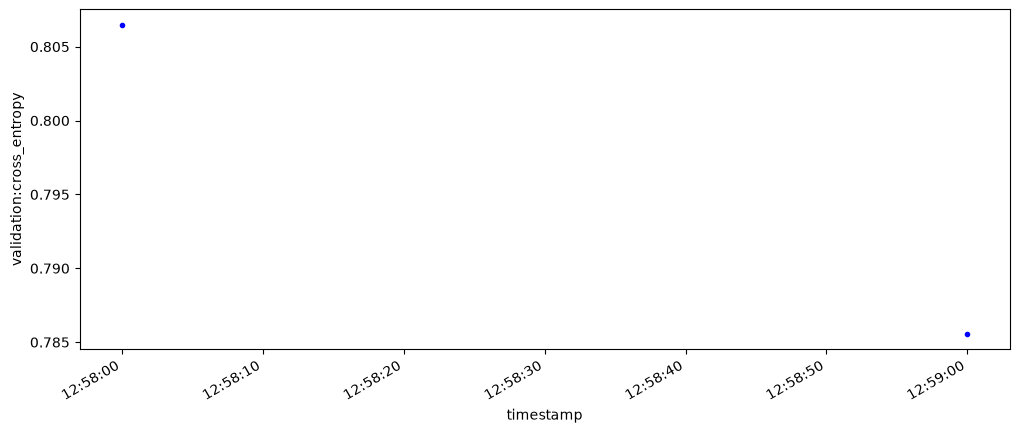

In [19]:
%matplotlib inline
import time
import pandas as pd
from datetime import datetime, timezone

# sagemaker.analytics is not available in V3; pull the training metric directly
# from CloudWatch (namespace /aws/sagemaker/TrainingJobs) using boto3 instead.
metric_name = "validation:cross_entropy"
cw = boto3.client("cloudwatch", region_name=region)

tj = TrainingJob.get(training_job_name)
start_time = tj.training_start_time or tj.creation_time
end_time = tj.training_end_time or datetime.now(timezone.utc)

response = cw.get_metric_statistics(
    Namespace="/aws/sagemaker/TrainingJobs",
    MetricName=metric_name,
    Dimensions=[{"Name": "TrainingJobName", "Value": training_job_name}],
    StartTime=start_time,
    EndTime=end_time,
    Period=60,
    Statistics=["Average"],
)

datapoints = sorted(response["Datapoints"], key=lambda d: d["Timestamp"])
if datapoints:
    metrics_dataframe = pd.DataFrame(
        [{"timestamp": d["Timestamp"], "value": d["Average"]} for d in datapoints]
    )
    plt = metrics_dataframe.plot(
        kind="line", figsize=(12, 5), x="timestamp", y="value", style="b.", legend=False
    )
    plt.set_ylabel(metric_name)
else:
    print(f"No CloudWatch datapoints found yet for {metric_name}.")

### Deploy trained algorithm and set input-output configuration for inference

In [20]:
from sagemaker.core.resources import Model, EndpointConfig, Endpoint
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant

suffix = strftime("%Y-%m-%d-%H-%M-%S", gmtime())
model_name_1 = f"object2vec-snli-{suffix}-model"
endpoint_config_name_1 = f"object2vec-snli-{suffix}-config"
endpoint_name_1 = f"object2vec-snli-{suffix}"

# Fetch the trained model artifacts from the training job.
model_data_1 = TrainingJob.get(training_job_name).model_artifacts.s3_model_artifacts

model_1 = Model.create(
    model_name=model_name_1,
    primary_container=ContainerDefinition(
        image=container,
        model_data_url=model_data_1,
    ),
    execution_role_arn=role,
)

endpoint_config_1 = EndpointConfig.create(
    endpoint_config_name=endpoint_config_name_1,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=model_name_1,
            instance_type="ml.m4.xlarge",
            initial_instance_count=1,
            initial_variant_weight=1,
        )
    ],
)

predictor1 = Endpoint.create(
    endpoint_name=endpoint_name_1,
    endpoint_config_name=endpoint_config_name_1,
)
predictor1.wait_for_status("InService")

                    INFO     Creating model resource.                                            ]8;id=12635226;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12635227;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

[07/13/26 13:00:08] INFO     Creating endpoint_config resource.                                  ]8;id=12635233;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12635234;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=12635240;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12635241;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 13:04:28] INFO     Final Resource Status: InService                                    ]8;id=12635247;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12635248;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

In [21]:
import json


def o2v_predict(endpoint, payload):
    """Invoke an Object2Vec endpoint with a JSON payload and decode the JSON response."""
    response = endpoint.invoke(
        body=json.dumps(payload).encode("utf-8"),
        content_type="application/json",
        accept="application/json",
    ).body.read()
    return json.loads(response)

### Invoke endpoint and do inference with trained model
- Suppose we deploy our trained model with the endpoint_name "seqseq-prelim-with-pretrain-3". Now we demonstrate how to do inference using our earlier model 

In [22]:
def calc_prediction_accuracy(predictions, labels):
    loss = 0
    for idx, s_and_l in enumerate(zip(predictions["predictions"], labels)):
        score, label = s_and_l
        plabel = np.argmax(score["scores"])
        loss += int(plabel != label["label"])
    return 1 - loss / len(labels)

### Send mini-batches of SNLI test data to the endpoint and evaluate our model

In [23]:
import math

# load SNLI test data
snli_test_path = os.path.join(SNLI_PATH, "snli-integer-test-.jsonl")
test_data_content = list()
test_label = list()

for line in read_jsonline(snli_test_path):
    test_data_content.append({"in0": line["in0"], "in1": line["in1"]})
    test_label.append({"label": line["label"]})

print("Evaluating test results on SNLI without pre-trained embedding...")


batch_size = 100
n_test = len(test_label)
n_batches = math.ceil(n_test / float(batch_size))
start = 0
agg_acc = 0
for idx in range(n_batches):
    if idx % 10 == 0:
        print(f"Evaluating the {idx+1}-th batch")
    end = (start + batch_size) if (start + batch_size) <= n_test else n_test
    payload = {"instances": test_data_content[start:end]}
    acc = calc_prediction_accuracy(o2v_predict(predictor1, payload), test_label[start:end])
    agg_acc += acc * (end - start + 1)
    start = end
print(f"The test accuracy is {agg_acc/n_test}")

Evaluating test results on SNLI without pre-trained embedding...
Evaluating the 1-th batch


Evaluating the 11-th batch


Evaluating the 21-th batch


Evaluating the 31-th batch


Evaluating the 41-th batch


...

Evaluating the 61-th batch


Evaluating the 71-th batch


Evaluating the 81-th batch


Evaluating the 91-th batch


The test accuracy is 0.6566987309989141


## Transfer learning
- We evaluate the trained model directly on STS16 **question-question** task
- See SemEval-2016 Task 1 paper (http://www.aclweb.org/anthology/S16-1081) for an explanation of the evaluation method and benchmarking results

The cells below provide details on how to combine vocabulary for STS and SNLI,and how to get glove pretrained embedding

### Functions to generate STS evaluation set (from sts-2016-test set)

In [24]:
def loadSTSFile(fpath=STS_PATH, datasets=["question-question"]):
    data = {}
    for dataset in datasets:
        sent1 = []
        sent2 = []
        for line in (
            io.open(fpath + f"/STS2016.input.{dataset}.txt", encoding="utf8").read().splitlines()
        ):
            splitted = line.split("\t")
            sent1.append(splitted[0])
            sent2.append(splitted[1])

        raw_scores = np.array(
            [
                x
                for x in io.open(fpath + f"/STS2016.gs.{dataset}.txt", encoding="utf8")
                .read()
                .splitlines()
            ]
        )

        not_empty_idx = raw_scores != ""

        gs_scores = [float(x) for x in raw_scores[not_empty_idx]]
        sent1 = np.array(sent1)[not_empty_idx]
        sent2 = np.array(sent2)[not_empty_idx]

        data[dataset] = (sent1, sent2, gs_scores)

    return data


def get_sts_data_iterator(fpath=STS_PATH, datasets=["question-question"]):
    data = loadSTSFile(fpath, datasets)
    for dataset in datasets:
        sent1, sent2, _ = data[dataset]
        for s1, s2 in zip(sent1, sent2):
            yield [s1, s2]


## preprocessing unit for STS test data


def convert_single_sts_to_integers(s1, s2, gs_label, tokenizer, word_dict):
    converted = []
    for s in [s1, s2]:
        converted.append(sentence_to_integers(s, tokenizer, word_dict))
    converted.append(gs_label)
    return converted


def convert_sts_to_integers(sent1, sent2, gs_labels, tokenizer, word_dict):
    for s1, s2, gs in zip(sent1, sent2, gs_labels):
        yield convert_single_sts_to_integers(s1, s2, gs, tokenizer, word_dict)


def make_sts_data(
    fpath=STS_PATH,
    vocab_path_prefix=SNLI_PATH,
    vocab_name="snli-vocab.json",
    dataset="question-question",
):
    """
    prepare test data; example: test_data['left'] = [{'in0':[1,2,3]}, {'in0':[2,10]}, ...]
    """
    test_data = {"left": [], "right": []}
    test_label = list()
    tokenizer = TreebankWordTokenizer()
    vocab_path = os.path.join(vocab_path_prefix, vocab_name)
    with open(vocab_path) as f:
        word_dict = json.load(f)
    data = loadSTSFile(fpath=fpath, datasets=[dataset])
    for s1, s2, gs in convert_sts_to_integers(*data[dataset], tokenizer, word_dict):
        test_data["left"].append({"in1": s1})
        test_data["right"].append({"in1": s2})
        test_label.append(gs)
    return test_data, test_label

Note, in `make_sts_data`, we pass both inputs (s1 and s2 to a single encoder; in this case, we pass them to 'in1'). This makes sure that both inputs are mapped by the same encoding function (we empirically found that this is crucial to achieve competitive embedding performance)

### Build vocabulary using STS corpus

In [25]:
def make_sts_full_vocab(dirname=STS_PATH, datasets=["question-question"], force=True):
    vocab_path = os.path.join(dirname, "sts-vocab.json")
    if not os.path.exists(vocab_path) or force:
        data_iter = get_sts_data_iterator(dirname, datasets)
        with open(vocab_path, "w") as write_file:
            word_to_id = build_vocab(
                data_iter,
                dataname="sts",
                num_words=50000,
                min_count=1,
                use_reserved_symbols=False,
                sort=True,
            )

            json.dump(word_to_id, write_file)


make_sts_full_vocab(force=False)

Define functions for embedding evaluation on STS16 question-question task

In [26]:
from scipy.stats import pearsonr, spearmanr
import math


def wrap_sts_test_data_for_eval(
    fpath=STS_PATH, vocab_path_prefix=".", vocab_name="all_vocab.json", dataset="question-question"
):
    """
    Prepare data for evaluation
    """
    test_data, test_label = make_sts_data(fpath, vocab_path_prefix, vocab_name, dataset)
    input1 = {"instances": test_data["left"]}
    input2 = {"instances": test_data["right"]}
    return [input1, input2, test_label]


def get_cosine_similarity(vec1, vec2):
    assert len(vec1) == len(vec2), "Vector dimension mismatch!"
    norm1 = 0
    norm2 = 0
    inner_product = 0
    for v1, v2 in zip(vec1, vec2):
        norm1 += v1**2
        norm2 += v2**2
        inner_product += v1 * v2
    return inner_product / math.sqrt(norm1 * norm2)


def eval_corr(predictor, eval_data):
    """
    input:
    param: predictor: Sagemaker deployed model
    eval_data: a list of [input1, inpu2, gs_scores]
    Evaluate pearson and spearman correlation between algorithm's embedding and gold standard
    """
    sys_scores = []
    input1, input2, gs_scores = (
        eval_data[0],
        eval_data[1],
        eval_data[2],
    )  # get this from make_sts_data
    embeddings = []
    for data in [input1, input2]:
        prediction = o2v_predict(predictor, data)
        embeddings.append(prediction["predictions"])

    for emb_pair in zip(embeddings[0], embeddings[1]):
        emb1 = emb_pair[0]["embeddings"]
        emb2 = emb_pair[1]["embeddings"]
        sys_scores.append(get_cosine_similarity(emb1, emb2))  # TODO: implement this

    results = {
        "pearson": pearsonr(sys_scores, gs_scores),
        "spearman": spearmanr(sys_scores, gs_scores),
        "nsamples": len(sys_scores),
    }
    return results

### Check overlap between SNLI and STS vocabulary

In [27]:
snli_vocab_path = os.path.join(SNLI_PATH, "snli-vocab.json")
sts_vocab_path = os.path.join(STS_PATH, "sts-vocab.json")

with open(sts_vocab_path) as f:
    sts_v = json.load(f)
with open(snli_vocab_path) as f:
    snli_v = json.load(f)

sts_v_set = set(sts_v.keys())
snli_v_set = set(snli_v.keys())

print(len(sts_v_set))
not_captured = sts_v_set.difference(snli_v_set)
print(not_captured)
print(f"\nThe number of words in STS not included in SNLI is {len(not_captured)}")
print(
    f"\nThis is {round(float(len(not_captured)/len(sts_v_set)), 2)} percent of the total STS vocabulary"
)

905
{'textured', 'transitive', 'acceptable', 'pecans', 'sealant', 'crawlspace', '401k', 'cons', 'adjustable', 'EU', 'dry/cure', 'realistically', 'GFCI', 'resigning', 'Shellac-based', 'shelf-life', 'faculty', 'IRA', 'stucco-like', 'affect', 'finger-picking', 'water-damaged', 'Quicken', 'redundant', 'grams', 'VS', 'recommend', 'porous', 'advisable', 'Colombian', 'Japan.', 'REALLY', 'Peer', 'Should', '/', 'Graduate', 'ESTA', 'GRE', 'StackOverflow', 'residency', 'ODI', 'slotted', 'discourse', 'Journals', 'asbestos', 'specks', 'EFTA', 'Glue', 'committees', 'Layover', 'Shower', 'stayfor', 'Reviewed', 'thesaurus', 'APA', 'tablature', 'employers', 'recessed', 'Dorian', 'underlayment', 'Phd', 're-heat', 'reward/benefits', 'mayonnaise', 'adhesive', 'fan/light', 'rejected', 'Economics', 'lag', 'Rollover', 'Mathematics', 'disadvantages', 'Moka', 'hours.', 'Hammerite', 'hole/gap', 'verb', 'w/light', 'Travelling', 'USB', 'Purpose', 'cancelled.', 'dimmer', 'Title', 'primer', 'Roth', 'narration', 'por

#### Since the percentage of vocabulary in STS not covered by SNLI is pretty large, we are going to include the uncovered words into our vocabulary and use the *GloVe* pretrained embedding to initialize our network. 

##### Intuitive reasoning for why this works

* Our algorithm will not have seen the ***uncovered words*** during training
* If we directly use integer representation of words during training, the unseen words will have zero correlation with words seen. 
  - This means the model cannot embed the unseen words in a manner that takes advantage of its training knowledge
* However, if we use pre-trained word embedding, then we expect that some of the unseen words will be close to the words that the algorithm has seen in the embedding space 

In [28]:
def combine_vocabulary(vocab_paths, new_vocab_path):
    wd_count = 0
    all_vocab = set()
    new_vocab = {}
    for vocab_path in vocab_paths:
        with open(vocab_path) as f:
            vocab = json.load(f)
            all_vocab = all_vocab.union(vocab.keys())
    for idx, wd in enumerate(all_vocab):
        new_vocab[wd] = idx
    print(f"The new vocabulary size is {idx+1}")
    with open(new_vocab_path, "w") as f:
        json.dump(new_vocab, f)


vocab_paths = [snli_vocab_path, sts_vocab_path]
new_vocab_path = "all_vocab.json"

combine_vocabulary(vocab_paths, new_vocab_path)

The new vocabulary size is 43669


## Get pre-trained GloVe word embedding and upload it to S3

- Our notebook storage is not enough to host the *GloVe* file. Fortunately, we have extra space in the `/tmp` folder that we can utilize: https://docs.aws.amazon.com/sagemaker/latest/dg/howitworks-create-ws.html
- You may use the bash script below to download and unzip *GloVe* in the `/tmp` folder and remove it after use

In [29]:
%%bash
# download glove file from website
mkdir /tmp/GloVe
curl -Lo /tmp/GloVe/glove.840B.zip http://nlp.stanford.edu/data/glove.840B.300d.zip
unzip /tmp/GloVe/glove.840B.zip -d /tmp/GloVe/
rm /tmp/GloVe/glove.840B.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                    

             Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0   

   0 --:--:-- --:--:-- --:--:--     0

  0   315    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


  0   353    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


...

 99 2075M   99 2068M    0     0  5132k      0  0:06:54  0:06:52  0:00:02 5062k

 99 2075M   99 2073M    0     0  5132k      0  0:06:54  0:06:53  0:00:01 5077k

100 2075M  100 2075M    0     0  5132k      0  0:06:54  0:06:54 --:--:-- 5073k


Archive:  /tmp/GloVe/glove.840B.zip


  inflating: /tmp/GloVe//glove.840B.300d.txt  

We next trim the original *GloVe* embedding file so that it just covers our combined vocabulary, and then we save the trimmed glove file in the newly created *GloVe* directory

In [30]:
!mkdir GloVe

mkdir: GloVe: File exists


In [31]:
import json

# credit: This preprocessing function is modified from the w2v preprocessing script in Facebook infersent codebase
# Infersent code license can be found at: https://github.com/facebookresearch/InferSent/blob/master/LICENSE


def trim_w2v(in_path, out_path, word_dict):
    # create word_vec with w2v vectors
    lines = []
    with open(out_path, "w") as outfile:
        with open(in_path) as f:
            for line in f:
                word, vec = line.split(" ", 1)
                if word in word_dict:
                    lines.append(line)

        print("Found %s(/%s) words with w2v vectors" % (len(lines), len(word_dict)))
        outfile.writelines(lines)


in_path = "/tmp/GloVe/glove.840B.300d.txt"
out_path = "GloVe/glove.840B-trim.txt"
with open("all_vocab.json") as f:
    word_dict = json.load(f)

trim_w2v(in_path, out_path, word_dict)

Found 39133(/43669) words with w2v vectors


In [32]:
# remember to remove the original GloVe embedding folder since it takes up a lot of space
!rm -r /tmp/GloVe/

## Reprocess training data (SNLI) with the combined vocabulary

Create a new directory called `all_vocab_datasets`, and copy snli raw json files and all_vocab file to it

In [33]:
%%bash

mkdir all_vocab_datasets

for SPLIT in train dev test
do
    cp snli_1.0/snli_1.0_${SPLIT}.jsonl all_vocab_datasets/
done

cp all_vocab.json all_vocab_datasets/

mkdir: all_vocab_datasets: File exists


Convert snli data to integers using the all_vocab file

In [34]:
make_snli_data(
    dirname="all_vocab_datasets",
    vocab_file="all_vocab.json",
    outfile_suffix="pretrain",
    force=False,
)

Let's see the size of this new vocabulary

In [35]:
all_vocab_path = "all_vocab.json"
all_vocab_size = get_vocab_size(all_vocab_path)
print("There are {} words in vocabulary {}".format(all_vocab_size, all_vocab_path))

There are 43669 words in vocabulary all_vocab.json


### Reset training environment

Note that when we combine the vocabulary of our training and test data, we should not fine-tune the GloVE embeddings, but instead, keep them fixed. Otherwise, it amounts to a bit of cheating -- training on test data! Thankfully, our hyper-parameter `enc0/1_freeze_pretrained_embedding` is set to `True` by default. Note that in the earlier training where we did not use pretrained embeddings, this parameter is inconsequential.

In [36]:
hyperparameters_2, input_channels_2 = set_training_environment(
    bucket,
    prefix,
    is_quick_run=True,
    is_pretrain=True,
    use_all_vocab={"vocab_size": all_vocab_size},
)

# In V3 there is no estimator.attach: we simply launch a new TrainingJob with the
# pretrain hyperparameters and the auxiliary (GloVe) channel added above.
training_job_name_2 = f"object2vec-snli-pretrain-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"

Uploaded train data to s3://sagemaker-us-west-1-729646638167/object2vec/input/train/snli-integer-train-pretrain.jsonl
Uploaded validation data to s3://sagemaker-us-west-1-729646638167/object2vec/input/validation/snli-integer-validation-pretrain.jsonl


Uploaded auxiliary data for initializing with pretrain-embedding to object2vec/input/auxiliary


In [37]:
%%time
# fit the new job using the new data (with pretrained embedding)
training_job_2 = TrainingJob.create(
    training_job_name=training_job_name_2,
    hyper_parameters=hyperparameters_2,
    algorithm_specification=AlgorithmSpecification(
        training_image=container,
        training_input_mode="File",
    ),
    role_arn=role,
    input_data_config=input_channels_2,
    output_data_config=OutputDataConfig(s3_output_path=output_path),
    resource_config=ResourceConfig(
        instance_type="ml.g4dn.xlarge",
        instance_count=1,
        volume_size_in_gb=30,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=360000),
)

training_job_2.wait(logs=True)
print(training_job_2.training_job_status)

[07/13/26 13:12:21] INFO     Creating training_job resource.                                     ]8;id=12641325;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12641326;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

Output()

[07/13/26 13:15:24] INFO     object2vec-snli-pretrain-2026-07-13-20-12-21/algo-1-1783973587:     ]8;id=12641331;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12641332;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             Docker entrypoint called with argument(s): train                                      

                    INFO     object2vec-snli-pretrain-2026-07-13-20-12-21/algo-1-1783973587:     ]8;id=12641337;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12641338;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             Running default environment configuration script                                      

                    INFO     object2vec-snli-pretrain-2026-07-13-20-12-21/algo-1-1783973587:     ]8;id=12641343;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12641344;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             Nvidia gpu devices, drivers and cuda toolkit versions (only                           
                             available on hosts with GPU):                                                         

...

                    INFO     object2vec-snli-pretrain-2026-07-13-20-12-21/algo-1-1783973587:     ]8;id=12642777;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12642778;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             [07/13/2026 20:16:18 INFO 139864031864640] Saved checkpoint to                        
                             "/tmp/tmpklub2qyu/state-0001.params"                                                  

                    INFO     object2vec-snli-pretrain-2026-07-13-20-12-21/algo-1-1783973587:     ]8;id=12642783;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12642784;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             [07/13/2026 20:16:18 INFO 139864031864640] Test data is not                           
                             provided.                                                                             

                    INFO     object2vec-snli-pretrain-2026-07-13-20-12-21/algo-1-1783973587:     ]8;id=12642789;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12642790;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             #metrics {"StartTime": 1783973777.9829862, "EndTime":                                 
                             1783973778.6738327, "Dimensions": {"Algorithm": "ObjectToVec",                        
                             "Host": "algo-1", "Operation": "training"}, "Metrics":                                
                             {"model.serialize.time": {"sum": 663.8550758361816, "count": 1,                       
                             "min": 663.8550758361816, "max": 663.8550758361816}, "setuptime":                     
                             {"sum": 6.421566009521484, "count": 1, "min": 6.421566009521484,                      
                             "max": 6.421566009521484}, "totaltime": {"sum": 62130.37180900574,                    
                             "count": 1, "min": 62130.37180900574, "max": 62130.37180900574}}}                     

[07/13/26 13:16:41] INFO     Final Resource Status: Completed                                    ]8;id=12642795;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12642796;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

Completed
CPU times: user 4.52 s, sys: 815 ms, total: 5.34 s
Wall time: 4min 19s


### Deploy and test the new model

In [38]:
suffix2 = strftime("%Y-%m-%d-%H-%M-%S", gmtime())
model_name_2 = f"object2vec-snli-pretrain-{suffix2}-model"
endpoint_config_name_2 = f"object2vec-snli-pretrain-{suffix2}-config"
endpoint_name_2 = f"object2vec-snli-pretrain-{suffix2}"

model_data_2 = TrainingJob.get(training_job_name_2).model_artifacts.s3_model_artifacts

model_2 = Model.create(
    model_name=model_name_2,
    primary_container=ContainerDefinition(
        image=container,
        model_data_url=model_data_2,
    ),
    execution_role_arn=role,
)

endpoint_config_2 = EndpointConfig.create(
    endpoint_config_name=endpoint_config_name_2,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=model_name_2,
            instance_type="ml.m4.xlarge",
            initial_instance_count=1,
            initial_variant_weight=1,
        )
    ],
)

predictor_2 = Endpoint.create(
    endpoint_name=endpoint_name_2,
    endpoint_config_name=endpoint_config_name_2,
)
predictor_2.wait_for_status("InService")

                    INFO     Creating model resource.                                            ]8;id=12648867;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12648868;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

[07/13/26 13:16:44] INFO     Creating endpoint_config resource.                                  ]8;id=12648873;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12648874;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=12648879;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12648880;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 13:21:03] INFO     Final Resource Status: InService                                    ]8;id=12648885;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12648886;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

We first check the test error on SNLI after adding pretrained embedding

In [39]:
# load SNLI test data
snli_test_path = os.path.join("all_vocab_datasets", "snli-integer-test-pretrain.jsonl")
test_data_content = list()
test_label = list()

for line in read_jsonline(snli_test_path):
    test_data_content.append({"in0": line["in0"], "in1": line["in1"]})
    test_label.append({"label": line["label"]})

print("Evaluating test results on SNLI with pre-trained embedding...")

batch_size = 100
n_test = len(test_label)
n_batches = math.ceil(n_test / float(batch_size))
start = 0
agg_acc = 0
for idx in range(n_batches):
    if idx % 10 == 0:
        print(f"Evaluating the {idx+1}-th batch")
    end = (start + batch_size) if (start + batch_size) <= n_test else n_test
    payload = {"instances": test_data_content[start:end]}
    acc = calc_prediction_accuracy(o2v_predict(predictor_2, payload), test_label[start:end])
    agg_acc += acc * (end - start + 1)
    start = end
print(f"The test accuracy is {agg_acc/n_test}")

Evaluating test results on SNLI with pre-trained embedding...
Evaluating the 1-th batch


Evaluating the 11-th batch


Evaluating the 21-th batch


Evaluating the 31-th batch


Evaluating the 41-th batch


...

Evaluating the 61-th batch


Evaluating the 71-th batch


Evaluating the 81-th batch


Evaluating the 91-th batch


The test accuracy is 0.5115092290988056



We next test the zero-shot transfer learning performance of our trained model on STS task

In [40]:
eval_data_qq = wrap_sts_test_data_for_eval(
    fpath=STS_PATH,
    vocab_path_prefix="all_vocab_datasets",
    vocab_name="all_vocab.json",
    dataset="question-question",
)

results = eval_corr(predictor_2, eval_data_qq)

pcorr = results["pearson"][0]
spcorr = results["spearman"][0]
print(f"The Pearson correlation to gold standard labels is {pcorr}")
print(f"The Spearman correlation to gold standard labels is {spcorr}")

The Pearson correlation to gold standard labels is 0.27823571090263943
The Spearman correlation to gold standard labels is 0.30599689359410465


In [41]:
## clean up
predictor1.delete()
endpoint_config_1.delete()
model_1.delete()

predictor_2.delete()
endpoint_config_2.delete()
model_2.delete()

[07/13/26 13:21:24] INFO     Deleting Endpoint - object2vec-snli-2026-07-13-20-00-07             ]8;id=12654958;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654959;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

                    INFO     Deleting EndpointConfig -                                           ]8;id=12654965;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654966;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\
                             object2vec-snli-2026-07-13-20-00-07-config                                            

                    INFO     Deleting Model - object2vec-snli-2026-07-13-20-00-07-model          ]8;id=12654972;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654973;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

                    INFO     Deleting Endpoint - object2vec-snli-pretrain-2026-07-13-20-16-43    ]8;id=12654978;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654979;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

[07/13/26 13:21:26] INFO     Deleting EndpointConfig -                                           ]8;id=12654984;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654985;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\
                             object2vec-snli-pretrain-2026-07-13-20-16-43-config                                   

                    INFO     Deleting Model - object2vec-snli-pretrain-2026-07-13-20-16-43-model ]8;id=12654990;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654991;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

## How to enable the optimal training result 

So far we have been training the algorithm with `is_quick_run` set to `True` (in `set_training_envirnoment` function); this is because we want to minimize the time for you to run through this notebook. If you want to yield the best performance of *Object2Vec* on the tasks above, we recommend setting `is_quick_run` to `False`. For example, with pretrained embedding used, we would re-run the code block under **Reset training environment** as the block below

<span style="color:red">Run with caution</span>: 
This may take a few hours to complete depending on the machine instance you are using

In [42]:
hyperparameters_2, input_channels_2 = set_training_environment(
    bucket,
    prefix,
    is_quick_run=False,  # modify is_quick_run flag here
    is_pretrain=True,
    use_all_vocab={"vocab_size": all_vocab_size},
)

# In V3, launch a new TrainingJob with the full-run hyperparameters (no estimator.attach).
training_job_name_full = f"object2vec-snli-pretrain-full-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"
training_job_full = TrainingJob.create(
    training_job_name=training_job_name_full,
    hyper_parameters=hyperparameters_2,
    algorithm_specification=AlgorithmSpecification(
        training_image=container,
        training_input_mode="File",
    ),
    role_arn=role,
    input_data_config=input_channels_2,
    output_data_config=OutputDataConfig(s3_output_path=output_path),
    resource_config=ResourceConfig(
        instance_type="ml.g4dn.xlarge",
        instance_count=1,
        volume_size_in_gb=30,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=360000),
)
# training_job_full.wait(logs=True)  # uncomment to run (may take a few hours)

Uploaded train data to s3://sagemaker-us-west-1-729646638167/object2vec/input/train/snli-integer-train-pretrain.jsonl
Uploaded validation data to s3://sagemaker-us-west-1-729646638167/object2vec/input/validation/snli-integer-validation-pretrain.jsonl


Uploaded auxiliary data for initializing with pretrain-embedding to object2vec/input/auxiliary


[07/13/26 13:21:30] INFO     Creating training_job resource.                                     ]8;id=12654996;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12654997;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

Then we can train and deploy the model as before; similarly, without pretrained embedding, the code block under **Train without using pretrained embedding** can be changed to below to optimize training result

<span style="color:red">Run with caution</span>: 
This may take a few hours to complete depending on the machine instance you are using

In [43]:
hyperparameters, input_channels = set_training_environment(
    bucket,
    prefix,
    is_quick_run=False,  # modify is_quick_run flag here
    is_pretrain=False,
    use_all_vocab={},
)

# In V3, launch a new TrainingJob with the full-run hyperparameters.
training_job_name_full_nopretrain = (
    f"object2vec-snli-full-{strftime('%Y-%m-%d-%H-%M-%S', gmtime())}"
)
training_job_full_nopretrain = TrainingJob.create(
    training_job_name=training_job_name_full_nopretrain,
    hyper_parameters=hyperparameters,
    algorithm_specification=AlgorithmSpecification(
        training_image=container,
        training_input_mode="File",
    ),
    role_arn=role,
    input_data_config=input_channels,
    output_data_config=OutputDataConfig(s3_output_path=output_path),
    resource_config=ResourceConfig(
        instance_type="ml.g4dn.xlarge",
        instance_count=1,
        volume_size_in_gb=30,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=360000),
)
# training_job_full_nopretrain.wait(logs=True)  # uncomment to run (may take a few hours)

Uploaded train data to s3://sagemaker-us-west-1-729646638167/object2vec/input/train/snli-integer-train.jsonl
Uploaded validation data to s3://sagemaker-us-west-1-729646638167/object2vec/input/validation/snli-integer-validation.jsonl


[07/13/26 13:21:32] INFO     Creating training_job resource.                                     ]8;id=12655002;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12655003;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

### Best training result

With `is_quick_run = False` and without pretrained embedding, our algorithm's test accuracy on SNLI dataset is 78.5%; with pretrained GloVe embedding, we see an improved test accuracy on SNLI dataset to 81.9% ! On STS data, you should expect the Pearson correlation to be around 0.61.

In addition to the training demonstrated in this notebook, we have also done benchmarking experiments on evaluated on both SNLI and STS data, with different hyperparameter configurations, which we include below.

In both charts, we compare against Facebook's Infersent algorithm (https://research.fb.com/downloads/infersent/). The chart on the left shows the additional experiment result on SNLI (using CNN or RNN encoders). The chart on the right shows the best experiment result of Object2Vec on STS.

<img style="float:left" src="o2v-exp-snli.png" width="430"> 
<img style="float:middle" src="o2v-exp-sts.png" width="430">

## Hyperparameter Tuning (Advanced) 
with Hyperparameter Optimization (HPO) service in Sagemaker

To yield optimal performance out of any machine learning algorithm often requires a lot of effort on parameter tuning. 
In this notebook demo, we have hidden the hard work of finding a combination of good parameters for the algorithm on SNLI data (again, the optimal parameters are only defined by running `set_training_environment` method with `is_quick_run=False`).

If you are keen to explore how to tune HP on your own, you may find the code blocks below helpful.

To find the best HP combinations for our task, we can do parameter tuning by launching HPO jobs either from 
- As a simple example, we demonstrate how to find the best `enc_dim` parameter using HPO service here

In [44]:
s3_uri_path = {}

for split in ["train", "validation"]:
    s3_uri_path[split] = input_path + f"{split}/snli-integer-{split}.jsonl"

On a high level, a HPO tuning job is nothing but a collection of multiple training jobs with different HP setups; Sagemaker HPO service compares the performance of different training jobs according to the **HPO tuning metric**, which is specified in the `tuning_job_config`.

- More info on how to manually launch hpo tuning jobs can be found here: 
https://docs.aws.amazon.com/sagemaker/latest/dg/automatic-model-tuning-ex-tuning-job.html

In [45]:
from sagemaker.core.shapes import (
    HyperParameterTuningJobConfig,
    ParameterRanges,
    IntegerParameterRange,
    ResourceLimits,
    HyperParameterTuningJobObjective,
)

tuning_job_config = HyperParameterTuningJobConfig(
    strategy="Bayesian",
    hyper_parameter_tuning_job_objective=HyperParameterTuningJobObjective(
        type="Maximize",
        metric_name="validation:accuracy",
    ),
    resource_limits=ResourceLimits(
        max_number_of_training_jobs=3,
        max_parallel_training_jobs=3,
    ),
    parameter_ranges=ParameterRanges(
        categorical_parameter_ranges=[],
        continuous_parameter_ranges=[],
        integer_parameter_ranges=[
            IntegerParameterRange(name="enc_dim", min_value="16", max_value="1024"),
        ],
    ),
)

The tuning metric `MetricName` we use here is called `validation:accuracy`, together with `Type` set to `Maximize`, since we are trying to maximize accuracy here (in case you want to minimize mean squared error, you can switch the tuning objective accordingly to `validation:mean_squared_error` and `Minimize`).

The syntax for defining the configuration of an individual training job in a HPO job is as below

In [46]:
from sagemaker.core.shapes import (
    HyperParameterTrainingJobDefinition,
    HyperParameterAlgorithmSpecification,
)

training_job_definition = HyperParameterTrainingJobDefinition(
    algorithm_specification=HyperParameterAlgorithmSpecification(
        training_image=container,
        training_input_mode="File",
    ),
    input_data_config=[
        Channel(
            channel_name="train",
            data_source=DataSource(
                s3_data_source=S3DataSource(
                    s3_data_type="S3Prefix",
                    s3_uri=s3_uri_path["train"],
                    s3_data_distribution_type="FullyReplicated",
                )
            ),
            content_type="application/jsonlines",
            compression_type="None",
        ),
        Channel(
            channel_name="validation",
            data_source=DataSource(
                s3_data_source=S3DataSource(
                    s3_data_type="S3Prefix",
                    s3_uri=s3_uri_path["validation"],
                    s3_data_distribution_type="FullyReplicated",
                )
            ),
            content_type="application/jsonlines",
            compression_type="None",
        ),
    ],
    output_data_config=OutputDataConfig(s3_output_path=output_path),
    resource_config=ResourceConfig(
        instance_type="ml.p3.8xlarge",
        instance_count=1,
        volume_size_in_gb=20,
    ),
    role_arn=role,
    static_hyper_parameters={
        "learning_rate": "0.0004",
        "mlp_dim": "512",
        "mlp_activation": "linear",
        "mlp_layers": "2",
        "output_layer": "softmax",
        "optimizer": "adam",
        "mini_batch_size": "8192",
        "epochs": "2",
        "bucket_width": "0",
        "early_stopping_tolerance": "0.01",
        "early_stopping_patience": "3",
        "dropout": "0",
        "weight_decay": "0",
        "enc0_max_seq_len": "82",
        "enc1_max_seq_len": "82",
        "enc0_network": "hcnn",
        "enc1_network": "enc0",
        "enc0_token_embedding_dim": "300",
        "enc0_layers": "auto",
        "enc0_cnn_filter_width": "3",
        "enc1_token_embedding_dim": "300",
        "enc1_layers": "auto",
        "enc1_cnn_filter_width": "3",
        "enc0_vocab_file": "",
        "enc1_vocab_file": "",
        "enc0_vocab_size": str(vocab_size),
        "enc1_vocab_size": str(vocab_size),
        "num_classes": "3",
        "_num_gpus": "auto",
        "_num_kv_servers": "auto",
        "_kvstore": "device",
    },
    stopping_condition=StoppingCondition(max_runtime_in_seconds=43200),
)

In [47]:
from sagemaker.core.resources import HyperParameterTuningJob

### Disclaimer

Running HPO tuning jobs means dispatching multiple training jobs with different HP setups; this could potentially incur a significant cost on your AWS account if you use the HP combinations that takes long hours to train.


In [48]:
# [exec-copy] Skipping actual HPO tuning-job launch to avoid extra billing.
# The V3 HyperParameterTuningJob.create(...) config objects above are built
# and validated; launching is intentionally disabled for the e2e run.
tuning_job_name = "hpo-o2v-test-exec-copy-skipped"
print("HPO launch skipped in execution copy.")

HPO launch skipped in execution copy.


You can then view and track the hyperparameter tuning jobs you launched on the sagemaker console (using the same account that you used to create the sagemaker client to launch these jobs)

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/build_and_train_models|sm-introduction_to_object2vec_sentence_similarity|sm-introduction_to_object2vec_sentence_similarity.ipynb)
